# Guard Bed Outlet Prediction Model Comparison

This notebook compares several regression models for predicting `H2O_out` and `impurity_out` from the synthetic guard bed dataset.

Models compared:
- Linear Regression
- Ridge
- Random Forest
- Extra Trees
- HistGradientBoosting
- XGBoost

Rules used in this notebook:
- Drop obvious leakage columns such as outlet species and removal efficiencies.
- Predict both targets with the same train/test split.
- Save the comparison table and the best model artifact.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

from xgboost import XGBRegressor

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "guard_bed_synthetic_dataset.csv"
MODEL_DIR = BASE_DIR / "artifacts"
MODEL_DIR.mkdir(exist_ok=True)

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(3000, 49)


,simulation_id,flow_mol_s,T_in_C,P_in_kPa,relative_humidity,H2O_in_ppmv,inlet_dew_point_C,CO2_in_vol_pct,N2_in_vol_pct,O2_in_vol_pct,...,impurity_removal_efficiency,H2O_out,H2O_out_ppmv,SO2_out_ppmv,NOx_out_ppmv,HCl_out_ppmv,H2S_out_ppmv,impurity_out,impurity_out_ppmv,pressure_drop_model_source
0,1,681.824413,38.603395,109.828930,0.851581,53047.161245,29.022517,13.545848,85.007431,1.446721,...,0.728479,17145.190016,17145.190016,1.302727,7.096187,0.276600,0.275010,8.950524,8.950524,calibrated_ergun_with_preprocessing_reference
1,2,683.291852,32.787745,104.449080,0.575024,27331.658950,27.664078,12.371519,80.799733,6.828747,...,0.830568,4813.092813,4813.092813,0.214782,1.254834,0.112808,0.129719,1.712144,1.712144,calibrated_ergun_with_preprocessing_reference
2,3,520.867332,44.404218,99.960320,0.641080,59639.862691,39.364717,15.649989,78.906983,5.443028,...,0.817488,13104.912201,13104.912201,0.195795,1.189320,0.208762,0.307772,1.901649,1.901649,calibrated_ergun_with_preprocessing_reference
3,4,560.706736,48.473739,101.253358,0.581159,65718.326926,44.950618,12.618772,85.252325,2.128902,...,0.819924,11173.958757,11173.958757,0.990711,1.648543,0.006788,0.055145,2.701188,2.701188,calibrated_ergun_with_preprocessing_reference
4,5,525.237047,43.160964,103.008854,0.593578,50227.410054,39.393236,12.557763,85.025694,2.416544,...,0.824378,8284.068071,8284.068071,0.667364,4.036912,0.052372,0.048059,4.804706,4.804706,calibrated_ergun_with_preprocessing_reference


In [3]:
target_cols = ["H2O_out", "impurity_out"]

leakage_cols = {
    "simulation_id",
    "H2O_out", "H2O_out_ppmv",
    "impurity_out", "impurity_out_ppmv",
    "SO2_out_ppmv", "NOx_out_ppmv", "HCl_out_ppmv", "H2S_out_ppmv",
    "moisture_removal_efficiency", "impurity_removal_efficiency",
    "pressure_drop_model_source",
}

feature_cols = [col for col in df.columns if col not in leakage_cols]
X = df[feature_cols].copy()
y = df[target_cols].copy()

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"Number of features: {len(feature_cols)}")
print(feature_cols)

Number of features: 37
['flow_mol_s', 'T_in_C', 'P_in_kPa', 'relative_humidity', 'H2O_in_ppmv', 'inlet_dew_point_C', 'CO2_in_vol_pct', 'N2_in_vol_pct', 'O2_in_vol_pct', 'PM2_5_in_mg_m3', 'mist_in_mg_m3', 'SO2_in_ppmv', 'NOx_in_ppmv', 'HCl_in_ppmv', 'H2S_in_ppmv', 'pretreatment_pm_efficiency', 'pretreatment_acid_efficiency', 'PM2_5_after_pretreatment_mg_m3', 'SO2_after_pretreatment_ppmv', 'NOx_after_pretreatment_ppmv', 'HCl_after_pretreatment_ppmv', 'H2S_after_pretreatment_ppmv', 'bed_length_m', 'bed_diameter_m', 'particle_diameter_m', 'bed_porosity', 'particle_sphericity', 'adsorbent_bulk_density_kg_m3', 'guard_bed_age_h', 'cycles_since_regen', 'gas_density_kg_m3', 'gas_viscosity_Pa_s', 'flow_actual_m3_s', 'superficial_velocity_m_s', 'Re_particle', 'residence_time_s', 'deltaP_guard_bed_kPa']


## Train/Test Split

A simple hold-out split is used here to compare models on the same test set.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
    ],
    remainder="drop",
)

In [5]:
models = {
    "LinearRegression": Pipeline([
        ("prep", preprocessor),
        ("model", LinearRegression()),
    ]),
    "Ridge": Pipeline([
        ("prep", preprocessor),
        ("model", Ridge(alpha=1.0)),
    ]),
    "RandomForest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=400,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ]),
    "ExtraTrees": Pipeline([
        ("prep", preprocessor),
        ("model", ExtraTreesRegressor(
            n_estimators=400,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ]),
    "HistGradientBoosting": Pipeline([
        ("prep", preprocessor),
        ("model", MultiOutputRegressor(
            HistGradientBoostingRegressor(
                max_depth=6,
                max_iter=400,
                learning_rate=0.05,
                random_state=RANDOM_STATE,
            )
        )),
    ]),
    "XGBoost": Pipeline([
        ("prep", preprocessor),
        ("model", MultiOutputRegressor(
            XGBRegressor(
                objective="reg:squarederror",
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_lambda=1.0,
                random_state=RANDOM_STATE,
                n_jobs=1,
            )
        )),
    ]),
}

In [6]:
metrics_rows = []
predictions = {}
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    trained_models[model_name] = model
    predictions[model_name] = y_pred

    for idx, target in enumerate(target_cols):
        mse = mean_squared_error(y_test[target], y_pred[:, idx])
        rmse = float(np.sqrt(mse))
        mae = mean_absolute_error(y_test[target], y_pred[:, idx])
        r2 = r2_score(y_test[target], y_pred[:, idx])
        metrics_rows.append({
            "model": model_name,
            "target": target,
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
        })

metrics_df = pd.DataFrame(metrics_rows).sort_values(["target", "rmse"]).reset_index(drop=True)
metrics_df

,model,target,rmse,mae,r2
0,XGBoost,H2O_out,663.192914,455.419511,0.993449
1,HistGradientBoosting,H2O_out,695.417501,487.714834,0.992797
2,LinearRegression,H2O_out,827.052855,624.166526,0.989811
3,ExtraTrees,H2O_out,992.753859,711.137122,0.985320
4,Ridge,H2O_out,1054.383558,779.340030,0.983440
5,RandomForest,H2O_out,1102.883425,796.451877,0.981882
6,XGBoost,impurity_out,0.293511,0.211047,0.993911
7,HistGradientBoosting,impurity_out,0.294439,0.212194,0.993872
8,Ridge,impurity_out,0.319459,0.245357,0.992787
9,LinearRegression,impurity_out,0.323057,0.247074,0.992623


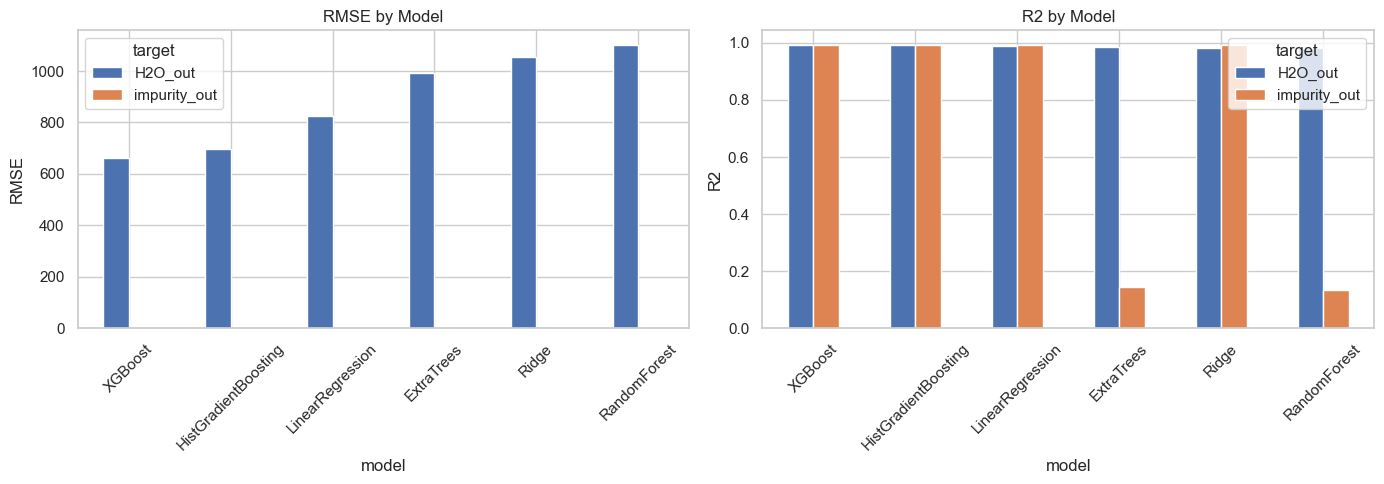

In [7]:
pivot_rmse = metrics_df.pivot(index="model", columns="target", values="rmse").sort_values("H2O_out")
pivot_r2 = metrics_df.pivot(index="model", columns="target", values="r2").sort_values("H2O_out", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot_rmse.plot(kind="bar", ax=axes[0], title="RMSE by Model")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=45)

pivot_r2.plot(kind="bar", ax=axes[1], title="R2 by Model")
axes[1].set_ylabel("R2")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Best Model Selection

The best model is selected by summing the RMSE ranks from both targets.

In [8]:
rank_df = metrics_df.copy()
rank_df["rmse_rank"] = rank_df.groupby("target")["rmse"].rank(method="dense")
model_rank_summary = (
    rank_df.groupby("model", as_index=False)["rmse_rank"]
    .sum()
    .sort_values("rmse_rank")
    .rename(columns={"rmse_rank": "rank_sum"})
)

best_model_name = model_rank_summary.iloc[0]["model"]
best_model = trained_models[best_model_name]

print(model_rank_summary)
print(f"Best model: {best_model_name}")

                  model  rank_sum
5               XGBoost       2.0
1  HistGradientBoosting       4.0
2      LinearRegression       7.0
4                 Ridge       8.0
0            ExtraTrees       9.0
3          RandomForest      12.0
Best model: XGBoost


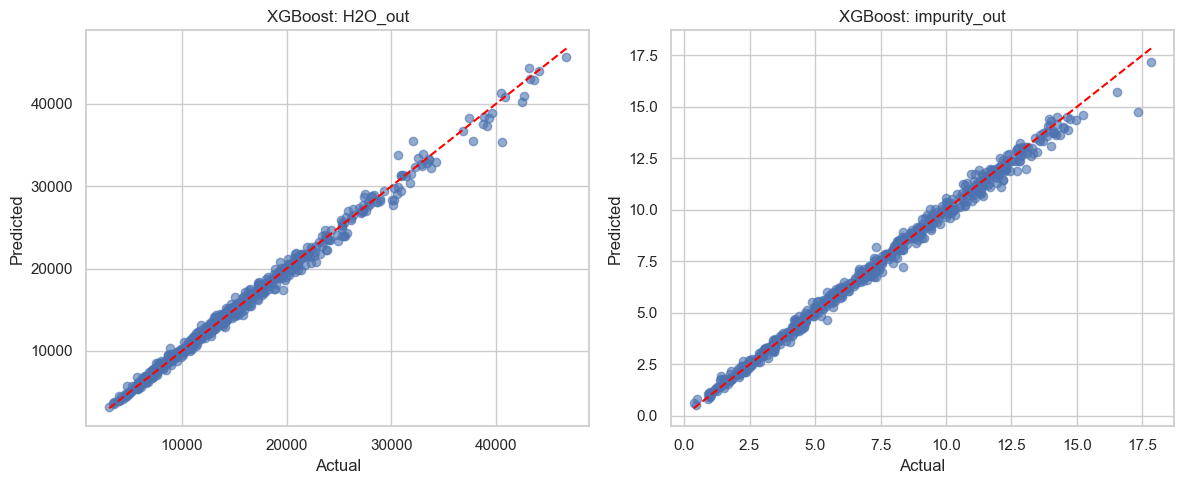

In [9]:
y_pred_best = predictions[best_model_name]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, target in enumerate(target_cols):
    ax = axes[i]
    ax.scatter(y_test[target], y_pred_best[:, i], alpha=0.6)
    lo = min(y_test[target].min(), y_pred_best[:, i].min())
    hi = max(y_test[target].max(), y_pred_best[:, i].max())
    ax.plot([lo, hi], [lo, hi], color="red", linestyle="--")
    ax.set_title(f"{best_model_name}: {target}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

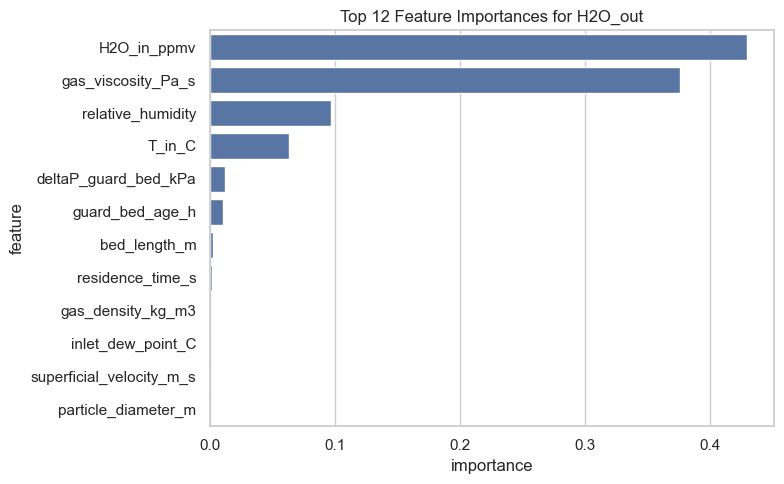

,feature,importance
4,H2O_in_ppmv,0.429712
31,gas_viscosity_Pa_s,0.376103
3,relative_humidity,0.096760
1,T_in_C,0.063213
36,deltaP_guard_bed_kPa,0.012281
28,guard_bed_age_h,0.010857
22,bed_length_m,0.002592
35,residence_time_s,0.001906
30,gas_density_kg_m3,0.000597
5,inlet_dew_point_C,0.000532


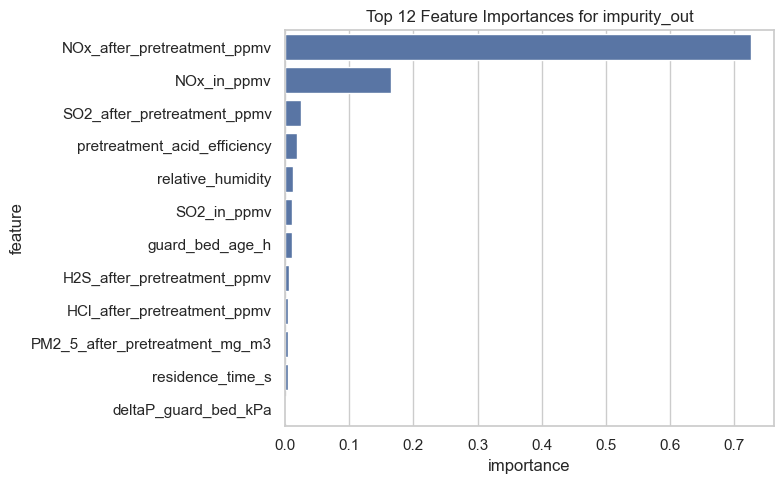

,feature,importance
19,NOx_after_pretreatment_ppmv,0.725430
12,NOx_in_ppmv,0.164720
18,SO2_after_pretreatment_ppmv,0.025588
16,pretreatment_acid_efficiency,0.018402
3,relative_humidity,0.012405
11,SO2_in_ppmv,0.011347
28,guard_bed_age_h,0.011169
21,H2S_after_pretreatment_ppmv,0.006825
20,HCl_after_pretreatment_ppmv,0.004340
17,PM2_5_after_pretreatment_mg_m3,0.004296


In [10]:
if best_model_name == "XGBoost":
    transformed_feature_names = numeric_features
    estimators = best_model.named_steps["model"].estimators_

    for target_name, estimator in zip(target_cols, estimators):
        importance_df = (
            pd.DataFrame({
                "feature": transformed_feature_names,
                "importance": estimator.feature_importances_,
            })
            .sort_values("importance", ascending=False)
            .head(12)
        )

        plt.figure(figsize=(8, 5))
        sns.barplot(data=importance_df, x="importance", y="feature")
        plt.title(f"Top 12 Feature Importances for {target_name}")
        plt.tight_layout()
        plt.show()

        display(importance_df)
else:
    print("Feature importance plotting is configured for XGBoost best model.")

In [11]:
metrics_path = MODEL_DIR / "model_comparison_metrics.csv"
best_model_path = MODEL_DIR / f"best_model_{best_model_name.lower()}.joblib"

metrics_df.to_csv(metrics_path, index=False)
joblib.dump(best_model, best_model_path)

print(f"Saved metrics to: {metrics_path}")
print(f"Saved best model to: {best_model_path}")

Saved metrics to: c:\Users\junhyun111\Desktop\psa\guard_bed\artifacts\model_comparison_metrics.csv
Saved best model to: c:\Users\junhyun111\Desktop\psa\guard_bed\artifacts\best_model_xgboost.joblib
